In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import numpy as np
from torch import optim

from torch.utils.data import TensorDataset, DataLoader

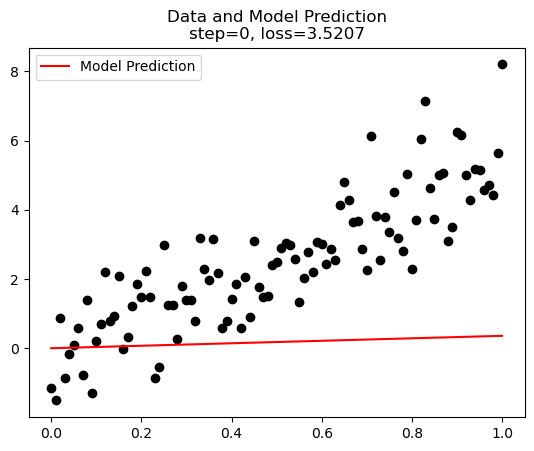

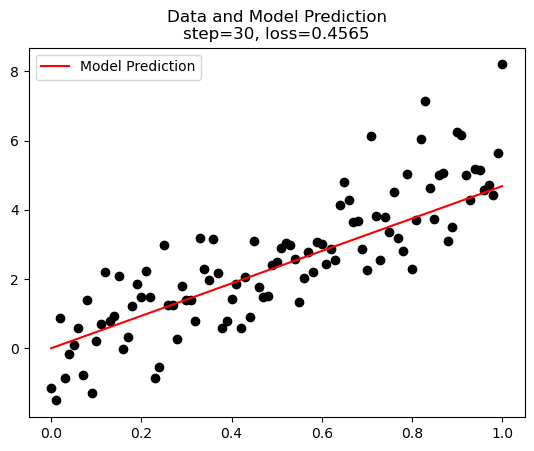

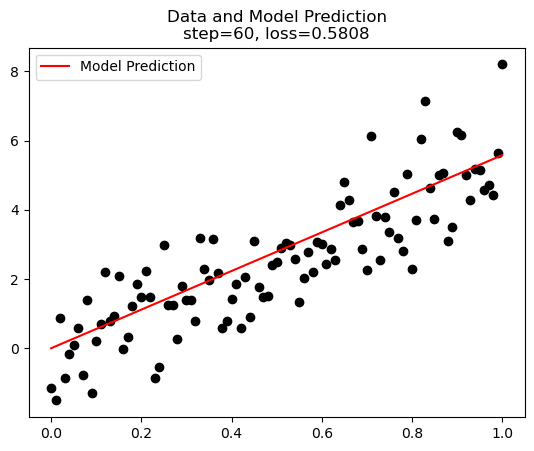

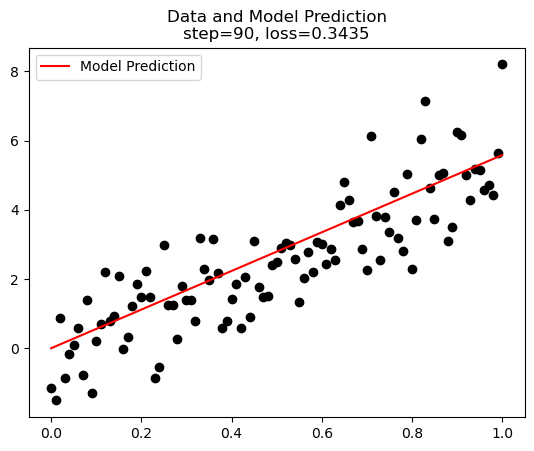

In [2]:
torch.manual_seed(2025)

x = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*x + torch.randn_like(x)

model = nn.Linear(1,1)

optimizer = optim.SGD(model.parameters(), lr=0.1)

dataset = TensorDataset(x, y_obs)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(100):
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = (y_pred - y_batch).square().mean()
        loss.backward()
        optimizer.step()

    if (epoch % 30) == 0:
        plt.figure()
        plt.title(f"Data and Model Prediction\nstep={epoch}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x, color="r", label="Model Prediction")
        plt.legend()
